# Importing the data

## Importing orders.csv file

In [2]:
import pandas as pd
df_orders = pd.read_csv('../data/raw/orders.csv')

print(df_orders.columns)
print(df_orders.shape)
df_orders.head()

Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='str')
(3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


## Importing order_products_train .csv file

In [4]:
# Reading data
df_orders_products_train = pd.read_csv('../data/raw/order_products_train.csv')
print(df_orders_products_train.columns)
print(df_orders_products_train.shape)
df_orders_products_train.head()

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='str')
(1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


## Importing products.csv file


In [5]:
df_products = pd.read_csv("../data/raw/products.csv")
df_products.head()

,product_id,product_name,aisle_id,department_id,prices
0,1,Chocolate Sandwich Cookies,61,19,5.8
1,2,All-Seasons Salt,104,13,9.3
2,3,Robust Golden Unsweetened Oolong Tea,94,7,4.5
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,10.5
4,5,Green Chile Anytime Sauce,5,13,4.3


## Importing departments_t.csv

In [6]:
df_departments = pd.read_csv('../data/processed/departments_t.csv')
print(df_departments.columns)
print(df_departments.shape)
df_departments.head()

Index(['department_id', 'department'], dtype='str')
(21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


## Importing aisles.csv

In [7]:
df_aisles = pd.read_csv('../data/raw/aisles.csv')
print(df_aisles.columns)
print(df_aisles.shape)
df_aisles.head()

Index(['aisle_id', 'aisle'], dtype='str')
(134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


# Data Dictionary

Before performing any analysis, we need to understand what each table represents.

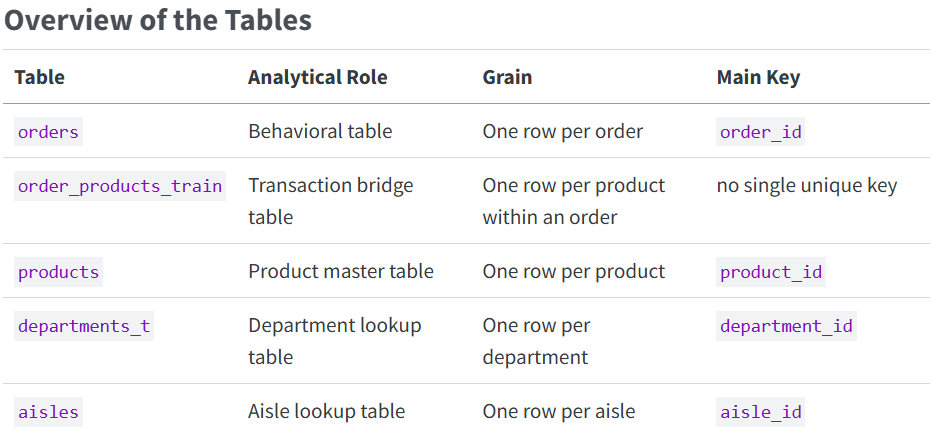

## The orders Table

Important columns:

* order_id: unique order identifier
* user_id: identifier of the customer
* eval_set: indicates whether the order belongs to prior, train, or test (we are going to use train)
* order_number: sequence number of the order for that user
* order_dow: day of week of the order
* order_hour_of_day: hour of day of the order
* days_since_prior_order: number of days since the customer’s previous order

Analytical questions that can be answered from this table alone:

* How many total orders are there?
* How many users are represented?
* What is the distribution of eval_set?
* On which days do customers place orders most frequently?
* At what hours do customers place orders most frequently?
* Are missing values in days_since_prior_order meaningful?

## The order_products_train Table

Important columns:

* order_id: identifier of the order
* product_id: identifier of the product
* add_to_cart_order: the sequence in which the product was added to the basket
* reordered: indicates whether the item had been ordered before by the same customer


** Important
* order_id is not unique in this table
* product_id is not unique in this table
* repeated values are expected because one order can contain many products, and one product can appear in many orders

Analytical questions that can be answered from this table alone:

* How many line items are there?
* How many unique orders are represented?
* How many unique products are represented?
* What proportion of items are reordered?
* What does the distribution of add_to_cart_order look like?

## The products Table

Important columns:

* product_id: unique identifier of the product
* product_name: product name
* aisle_id: identifier of the aisle
* department_id: identifier of the department

Analytical questions that can be answered from this table alone:

* How many products exist?
* Are product IDs unique?
* How many departments are represented in the product catalog?
* How many aisles are represented in the product catalog?
* Do some product names repeat?

## The departments_t Table

Important columns:

* department_id: unique department identifier
* department: department name

Analytical questions that can be answered from this table alone:

* How many departments exist?
* Are department IDs unique?

## The aisles Table

Important columns:

* aisle_id: unique aisle identifier
* aisle: aisle name

Analytical questions that can be answered from this table alone:

* How many aisles exist?
* Are aisle IDs unique?

# Relationship Between the Tables

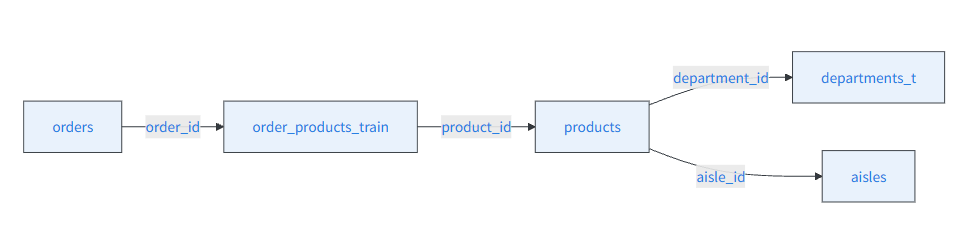

Before using pd.merge(), it is good analytical practice to inspect each table independently.

This allows us to:

* understand the grain of the data
* identify key columns
* find missing values
* check whether IDs are unique where they should be unique
* detect possible problems before combining tables

## Exploring the orders

Each row in this table represents one order placed by one user.

### Previewing the data

Helps that What variables are available for analysis?

In [8]:
df_orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


The output helps us answer two important structural questions:

* How many rows and columns does the table have?
* What variables are available for analysis?

### Inspecting the schema

This helps us understand the data types and whether missing values are present.

In [9]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 182.7 MB


### Looking at data types

Each column has a specific role, and its data type should match its meaning.

- order_id                    int64
- user_id                     int64
- eval_set                      str
- order_number                int64
- order_dow                   int64
- order_hour_of_day           int64
- days_since_prior_order    float64
- dtype: object

### Descriptive statistics

For numeric columns, descriptive statistics provide a first summary of the data.

In [10]:
df_orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


option for data reporting in order to make the value more representative.

In [11]:
pd.options.display.float_format = '{:,.2f}'.format
df_orders.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,"3,421,083.00","3,421,083.00","3,421,083.00","3,421,083.00","3,421,083.00","3,214,874.00"
mean,"1,710,542.00","102,978.21",17.15,2.78,13.45,11.11
std,"987,581.74","59,533.72",17.73,2.05,4.23,9.21
min,1.00,1.00,1.00,0.00,0.00,0.00
25%,"855,271.50","51,394.00",5.00,1.00,10.00,4.00
50%,"1,710,542.00","102,689.00",11.00,3.00,13.00,7.00
75%,"2,565,812.50","154,385.00",23.00,5.00,16.00,15.00
max,"3,421,083.00","206,209.00",100.00,6.00,23.00,30.00


### Missing values

.isna(): Goes through your entire DataFrame and changes every cell to True if it is empty, and False if it has data.

.sum(): Because Python treats True as 1 and False as 0, adding them up gives you the exact count of missing cells for each column.

In [28]:
df_orders.isna().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

### Analytical questions for orders

#### Q1: How many unique orders exist?

Total Unique Orders: 3,421,083. This means there are over 3.4 million transactions recorded in the system.

In [29]:
df_orders["order_id"].nunique()

3421083

#### Q2: How many distinct customers are represented in the dataset?

Total Distinct Customers: 206,209. This shows the platform has over 200,000 active users making those 3.4 million orders.

In [30]:
df_orders["user_id"].nunique()

206209

#### Q3: Exploring the eval_set distribution

The eval_set variable is very important because it determines which subset of orders we will use later in the analysis.

This helps us understand how the orders are split into

.value_counts(): The function that scans the selected column and adds up the occurrences of each unique value, automatically sorting the results from the most frequent to the least frequent.

dropna=False: A vital data cleaning safety flag. By default, .value_counts() ignores rows with missing values (NaN). By setting dropna=False, you force Pandas to count and display missing values as well, ensuring you know if there are hidden gaps in the column.

In [31]:
df_orders["eval_set"].value_counts(dropna=False)

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

#### Q4: Orders by day of week

This tells us how orders are distributed across the week. We can now begin exploring ordering behavior.

In [32]:
df_orders["order_dow"].value_counts().sort_index()

order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64

A useful analytical question here is: Are some days clearly more active than others?

#### Q5: Orders by hour of day

Next, we examine the hourly distribution of orders.

- At what time of day do customers shop most often?
- Is ordering behavior concentrated in a small time window?

In [33]:
df_orders["order_hour_of_day"].value_counts().sort_index()

order_hour_of_day
0      22758
1      12398
2       7539
3       5474
4       5527
5       9569
6      30529
7      91868
8     178201
9     257812
10    288418
11    284728
12    272841
13    277999
14    283042
15    283639
16    272553
17    228795
18    182912
19    140569
20    104292
21     78109
22     61468
23     40043
Name: count, dtype: int64

#### Q6:Understanding missing values in days_since_prior_order

missing values may actually have a logical explanation.

In [34]:
df_orders["days_since_prior_order"].isna().sum()

np.int64(206209)

Could these null values correspond to the first order of each user?

Logical check: first orders and null values

In [35]:
df_orders.loc[df_orders["order_number"] == 1, "days_since_prior_order"].isna().all()

np.True_

* not every null is a problem
* some null values reflect the business logic of the data

### basic consistency checks

#### Is order_id unique?

Since each row should represent one order, order_id should uniquely identify rows.

In [36]:
df_orders["order_id"].is_unique

True

#### Is order_dow in the correct range?


Day of week should logically be between 0 and 6.



In [3]:
df_orders["order_dow"].between(0, 6).all()

np.True_

#### Is order_hour_of_day in the correct range?

Hour of day should logically be between 0 and 23.

In [38]:
df_orders["order_hour_of_day"].between(0, 23).all()

np.True_

### Filtering the orders table to train orders

In [39]:
df_orders_train = df_orders[df_orders["eval_set"] == "train"]
df_orders_train.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.00
25,1492625,2,train,15,1,11,30.00
49,2196797,5,train,5,0,11,6.00
74,525192,7,train,21,2,11,6.00
78,880375,8,train,4,1,14,10.00


Filter is an important analytical step

* order_products_train.csv contains only products from train orders
* filtering first keeps the analysis focused and consistent
* this is similar to applying a WHERE condition before a JOIN in SQL

keep only the most relevant columns from the filtered table.

In [40]:
df_orders_train.drop(columns=["eval_set"])
df_orders_train.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
10,1187899,1,train,11,4,8,14.00
25,1492625,2,train,15,1,11,30.00
49,2196797,5,train,5,0,11,6.00
74,525192,7,train,21,2,11,6.00
78,880375,8,train,4,1,14,10.00


Summary of the orders table

At this stage, we understand the orders table both structurally and analytically.

* It is a behavioral table with one row per order
* It helps us study timing and frequency of customer orders
* It introduces the important eval_set variable
* It provides a good example of meaningful null values
* It allows us to prepare the correct subset before merging with the train basket table

## Exploring the order_products_train

### Previewing the data

In [41]:
df_orders_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


* What does one row represent in this table?
* Which columns help us connect orders to products?

### Inspecting the schema

In [42]:
df_orders_products_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           1384617 non-null  int64
 1   product_id         1384617 non-null  int64
 2   add_to_cart_order  1384617 non-null  int64
 3   reordered          1384617 non-null  int64
dtypes: int64(4)
memory usage: 42.3 MB


### Looking at data types

In [43]:
df_orders_products_train.dtypes

order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object

### Descriptive statistics

In [44]:
df_orders_products_train.describe()

,order_id,product_id,add_to_cart_order,reordered
count,"1,384,617.00","1,384,617.00","1,384,617.00","1,384,617.00"
mean,"1,706,297.62","25,556.24",8.76,0.60
std,"989,732.65","14,121.27",7.42,0.49
min,1.00,1.00,1.00,0.00
25%,"843,370.00","13,380.00",3.00,0.00
50%,"1,701,880.00","25,298.00",7.00,1.00
75%,"2,568,023.00","37,940.00",12.00,1.00
max,"3,421,070.00","49,688.00",80.00,1.00


### Missing values

In [45]:
df_orders_products_train.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

### Analytical questions for order_products_train

* How many line items are there in total?
* How many unique orders are represented?
* How many unique products are represented?
* What is the distribution of reordered?
* What does add_to_cart_order tell us about basket construction?
* Are there any suspicious or inconsistent values?

#### Q1: How many line items exist?

In [46]:
len(df_orders_products_train)

1384617

#### Q2: How many unique orders are represented in this table?

In [47]:
df_orders_products_train["order_id"].nunique()

131209

#### Q3: How many unique products are represented in this table?

In [48]:
df_orders_products_train["product_id"].nunique()

39123

#### Q4: Exploring reorder behavior

This helps us understand how the product rows are split into:

In [49]:
df_orders_products_train["reordered"].value_counts(dropna=False)

reordered
1    828824
0    555793
Name: count, dtype: int64

#### Q5: Reorder share

Instead of only counts, we can also look at proportions.

In [50]:
df_orders_products_train["reordered"].value_counts(normalize=True)

reordered
1   0.60
0   0.40
Name: proportion, dtype: float64

#### Q6: Understanding add_to_cart_order

This variable tells us the sequence in which a product was added to the cart.

In [51]:
df_orders_products_train["add_to_cart_order"].describe()

count   1,384,617.00
mean            8.76
std             7.42
min             1.00
25%             3.00
50%             7.00
75%            12.00
max            80.00
Name: add_to_cart_order, dtype: float64

* Are most products added early in the basket-building process?
* How large do baskets tend to become?

#### Q7: Which cart positions appear most often?

In [52]:
df_orders_products_train["add_to_cart_order"].value_counts().sort_index().head(20)

add_to_cart_order
1     131209
2     124364
3     116996
4     108963
5     100745
6      91850
7      83142
8      74601
9      66618
10     59401
11     52848
12     46814
13     41431
14     36588
15     32194
16     28363
17     24841
18     21733
19     19014
20     16541
Name: count, dtype: int64

## Understanding repeated keys in the table

This table behaves differently from orders.

In [53]:
df_orders_products_train["order_id"].is_unique

False

In [54]:
df_orders_products_train["product_id"].is_unique

False

If these results are False, that is expected.